In [19]:
import matplotlib.pyplot as plt
import os
#from utilites import read_data_from_timestep
import numpy as np
import pandas as pd
import csv


rho_ratio = '1'
v = '001'
U='01'


folder_path_moving = os.path.join("~/DATA_FOR_PLOTS",
                           "moving_vs_resting_bubble",
                           "rel_bubble")

n = np.arange(0, 199, 1)  # [from, to, step]

diam_x_cm = np.empty(len(n))   # x coordinate of the center of mass of the bubble
Ux = np.empty(len(n))
for i in n:
    def load_data(path):
        try:
            frame_moving = pd.read_csv(path, delimiter=",")              
            return frame_moving     
        except FileNotFoundError:
            print(f"Wrong file or file path: {path}")
            return None
                     
    frame_cm = load_data(os.path.join(folder_path_moving, f"rel_bubble.{i}.csv"))    

    def find_diameter(frame, threshold=0.5): 
        if frame is None:
            return None
                                      
        # paraview dumps 1001 grid points from line plot, 
        # while simluation domain is 256 
        x_max = max(frame['Points:0']) # 256
        n= len(frame['Points:0'])  # 1001
        scale_factor =x_max/n

        counter = 0
        for y_ in frame['PhaseField']:
            counter += y_
#             if y_ > threshold:
#                 counter += 1

        ans = counter*scale_factor
        return ans
    
    Ux[i] = frame_cm['U:0'].mean()
    diam_x_cm[i] = find_diameter(frame_cm)
                            

<Figure size 1152x576 with 0 Axes>

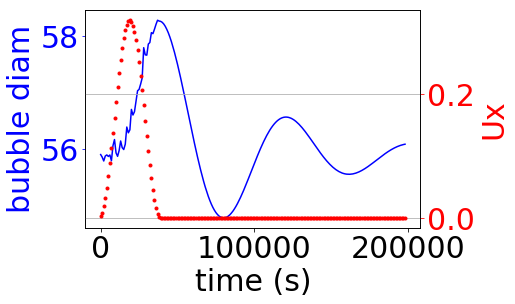

In [27]:
# make plot all in one
# def make_plot(x1, y1, x2, y2, fig_name, y_label, label1, label2):
plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(16, 8))
# The basic slice syntax is i:j:k where i is the starting index, j is the stopping index, and k is the step

x = n*1E3

# def smooth(x, y):
#     to_skip = 1
#     new_x = x[0:len(x):to_skip]
#     new_y = y[0:len(x):to_skip]

# #         xnew = np.linspace(0, max(x), num=len(x), endpoint=False)
#     f = interp1d(x, y)
#     f2 = interp1d(x, y, kind='cubic')
#     return new_x, f2(new_x)

# #     x1, y1 =  smooth(x1, y1)
# #     x1, y1 =  smooth(x1, y1)

# # plt.plot(x, diam_x_cm, color="red", marker="D", markevery=25,  markersize=10, linestyle="-", linewidth=2, label='bubble diam')
# plt.plot(x, Ux, color="blue", marker="o", markevery=25,  markersize=10, linestyle="-", linewidth=2, label='U')

# # plt.plot(x, diam_x_mrt_resting, color="green", marker="v", markevery=25,  markersize=10, linestyle="-", linewidth=2, label="MRT resting frame")
# # plt.plot(x, diam_x_mrt_moving, color="purple", marker="*", markevery=25,  markersize=10, linestyle=":", linewidth=2, label="MRT moving frame")


# axes = plt.gca()
# # axes.set_xlim([0, 2*1E5])
# # axes.set_ylim([50, 110])
# plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
# #     plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
# plt.xlabel(r'iterations')
# plt.ylabel(r'$d_x$ [lu]')
# plt.grid(True)
# plt.legend()

# fig = plt.gcf()  # get current figure
# fig.savefig(f'rel_bubble_diam.png', )
# plt.show()
# plt.close(fig)    # close the figure


fig, ax1 = plt.subplots()

ax1.plot(x, diam_x_cm, 'b-')
ax1.set_xlabel('time (s)')
# Make the y-axis label, ticks and tick labels match the line color.
ax1.set_ylabel('bubble diam', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(x, Ux, 'r.')
ax2.set_ylabel('Ux', color='r')
ax2.tick_params('y', colors='r')
plt.grid(True)